# 🍠 Analisis Bisnis Es Ubi Ungu (Studi Kasus Kalkulus)

Laporan ini menyajikan analisis mendalam menggunakan format pengerjaan buku tulis terstruktur.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import integrate
import sympy as sp

plt.style.use('seaborn-v0_8-muted')
plt.rcParams.update({'figure.figsize': (8, 5), 'figure.dpi': 100})
print('✅ Library Siap!')

✅ Library Siap!


## 1. 💰 Model Biaya Produksi (Integral Dasar)

### 📊 1. Data Hasil Observasi
**Diketahui:**
- Biaya Marginal ($MC$): Rp $5.500 + 2x$ per cup
- Biaya Tetap ($FC$): Rp $100.000$ (Sewa & Gaji)

### 📐 2. Model Matematika
Fungsi biaya total $C(x)$ adalah integral dari biaya marginal:
$$C(x) = \int MC \, dx = \int (5.500 + 2x) \, dx$$

### 🧮 3. Perhitungan Integral (Step-by-Step)
**Ditanya:** Fungsi $C(x)$?

**Dijawab:**
1. Pisahkan suku-suku integral:
   $$C(x) = \int 5.500 \, dx + \int 2x \, dx$$
2. Gunakan aturan pangkat integral:
   $$C(x) = 5.500x + 2 \left( \frac{1}{2}x^2 \right) + C$$
   $$C(x) = 5.500x + x^2 + C$$
3. Tentukan konstanta $C$ menggunakan nilai $FC$:
   $$C(x) = x^2 + 5.500x + 100.000$$

### 📈 4. Analisis Hasil
Berikut adalah tabel estimasi biaya untuk berbagai jumlah produksi:

In [2]:
x_vals = [0, 20, 40, 60, 80, 100]
costs = [(x**2 + 5500*x + 100000) for x in x_vals]
df_cost = pd.DataFrame({'Jumlah Cup (x)': x_vals, 'Total Biaya (Rp)': costs})
print(df_cost.to_string(index=False))

 Jumlah Cup (x)  Total Biaya (Rp)
              0            100000
             20            210400
             40            321600
             60            433600
             80            546400
            100            660000


### 🏁 5. Kesimpulan Optimasi
Fungsi biaya kuadratik ini menunjukkan bahwa biaya total meningkat secara perlahan di awal, namun akan melonjak tajam jika produksi dipaksakan melebihi kapasitas alat (karena adanya variabel $x^2$).

## 2. 📈 Pendapatan & Luas Daerah

### 📊 1. Data Hasil Observasi
**Diketahui:**
- Harga Jual ($p$): Rp $10.000$ per cup
- Target Penjualan: $0$ sampai $35$ cup

### 📐 2. Model Matematika
Total Pendapatan adalah luas daerah di bawah kurva harga:
$$R = \int_{a}^{b} p \, dx$$

### 🧮 3. Perhitungan Integral (Step-by-Step)
**Ditanya:** Total Pendapatan $R$?

**Dijawab:**
1. Susun integral dengan batas $0$ sampai $35$:
   $$R = \int_{0}^{35} 10.000 \, dx$$
2. Integralkan fungsi konstan:
   $$R = [10.000x]_{0}^{35}$$
3. Evaluasi batas atas dan bawah:
   $$R = (10.000 \cdot 35) - (10.000 \cdot 0)$$
   $$R = 350.000$$

### 📈 4. Analisis Hasil
Visualisasi area pendapatan (luas daerah di bawah garis harga):

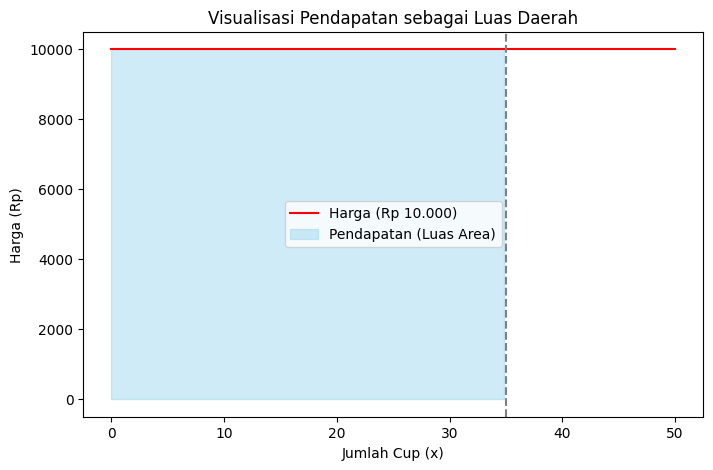

In [3]:
x = np.linspace(0, 50, 100)
y = np.full_like(x, 10000)
plt.plot(x, y, 'r-', label='Harga (Rp 10.000)')
plt.fill_between(x, y, where=(x <= 35), color='skyblue', alpha=0.4, label='Pendapatan (Luas Area)')
plt.axvline(35, color='gray', linestyle='--')
plt.title('Visualisasi Pendapatan sebagai Luas Daerah')
plt.xlabel('Jumlah Cup (x)')
plt.ylabel('Harga (Rp)')
plt.legend()
plt.show()

### 🏁 5. Kesimpulan Optimasi
Target pendapatan Rp 350.000 tercapai tepat pada volume penjualan 35 cup. Area biru menunjukkan total akumulasi uang masuk.

## 3. 🫙 Desain Volume Botol (Tabung)

### 📊 1. Data Hasil Observasi
**Diketahui:**
- Jari-jari botol ($r$): $4.5$ cm
- Tinggi botol ($h$): $12$ cm

### 📐 2. Model Matematika
Volume benda putar untuk silinder (tabung):
$$V = \pi \int_{0}^{h} r^2 \, dy$$

### 🧮 3. Perhitungan Integral (Step-by-Step)
**Ditanya:** Volume total $V$?

**Dijawab:**
1. Masukkan nilai $r$ dan $h$:
   $$V = \pi \int_{0}^{12} (4.5)^2 \, dy$$
2. Kuadratkan jari-jari:
   $$V = \pi \int_{0}^{12} 20.25 \, dy$$
3. Integralkan terhadap $y$:
   $$V = \pi [20.25y]_{0}^{12}$$
4. Hitung hasil akhir:
   $$V = \pi (20.25 \cdot 12 - 0) = 243\pi$$
   $$V \approx 763.4 \text{ ml}$$

### 📈 4. Analisis Hasil
Profil botol jika dilihat dari samping (sumbu putar):

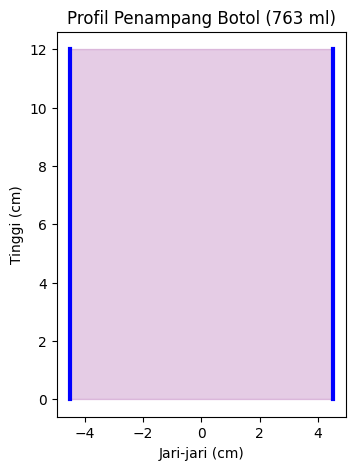

In [4]:
y_profile = np.linspace(0, 12, 100)
r_profile = np.full_like(y_profile, 4.5)
plt.plot(r_profile, y_profile, 'b-', linewidth=3)
plt.plot(-r_profile, y_profile, 'b-', linewidth=3)
plt.fill_betweenx(y_profile, -r_profile, r_profile, color='purple', alpha=0.2)
plt.title('Profil Penampang Botol (763 ml)')
plt.xlabel('Jari-jari (cm)')
plt.ylabel('Tinggi (cm)')
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

### 🏁 5. Kesimpulan Optimasi
Botol dengan dimensi ini memiliki kapasitas cukup besar (±760 ml), yang ideal untuk kemasan sharing atau ukuran *large*.

## 4. 🌿 Model Pertumbuhan Penjualan

### 📊 1. Data Hasil Observasi
**Diketahui:**
- Penjualan hari ke-0 ($N_0$): $32$ cup
- Penjualan hari ke-6 ($N_6$): $70$ cup

### 📐 2. Model Matematika
$$N(t) = N_0 \cdot e^{kt}$$

### 🧮 3. Perhitungan (Step-by-Step)
**Ditanya:** Laju $k$ dan prediksi hari ke-14?

**Dijawab:**
1. Cari nilai $k$:
   $$70 = 32 \cdot e^{6k} \implies \frac{70}{32} = e^{6k}$$
   $$\ln(2.1875) = 6k \implies 0.7827 = 6k$$
   $$k = 0.1305$$
2. Hitung $N(14)$:
   $$N(14) = 32 \cdot e^{0.1305 \cdot 14}$$
   $$N(14) \approx 199 \text{ cup}$$

### 📈 4. Analisis Hasil
Grafik tren pertumbuhan penjualan:

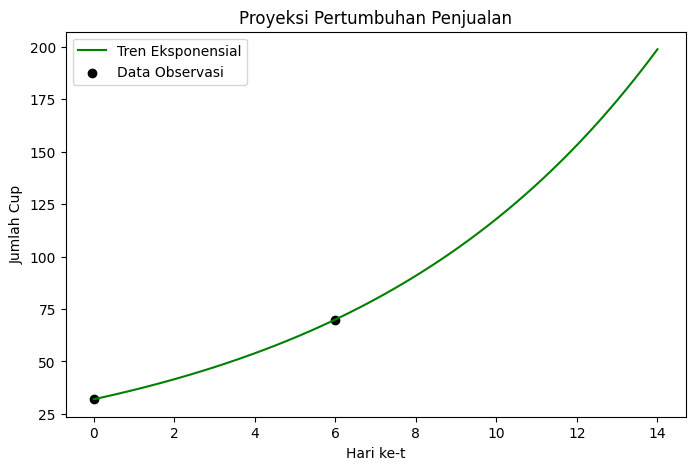

In [5]:
t = np.linspace(0, 14, 100)
n_t = 32 * np.exp(0.1305 * t)
plt.plot(t, n_t, 'g-', label='Tren Eksponensial')
plt.scatter([0, 6], [32, 70], color='black', label='Data Observasi')
plt.title('Proyeksi Pertumbuhan Penjualan')
plt.xlabel('Hari ke-t')
plt.ylabel('Jumlah Cup')
plt.legend()
plt.show()

### 🏁 5. Kesimpulan Optimasi
Bisnis memiliki laju pertumbuhan harian sebesar **13.05%**. Jika konsisten, stok bahan baku harus ditingkatkan 3x lipat pada minggu kedua.

## 5. 🎯 Optimasi Keuntungan

### 📊 1. Data Hasil Observasi
**Diketahui:**
- Fungsi Biaya $C(x) = x^2 + 5.500x + 100.000$
- Fungsi Pendapatan $R(x) = 10.000x$

### 📐 2. Model Matematika
Fungsi Keuntungan (Profit):
$$\pi(x) = R(x) - C(x) = -x^2 + 4.500x - 100.000$$

### 🧮 3. Perhitungan Turunan (Step-by-Step)
**Ditanya:** Nilai $x$ untuk profit maksimal?

**Dijawab:**
1. Cari turunan pertama $\pi'(x)$:
   $$\pi'(x) = \frac{d}{dx}(-x^2 + 4.500x - 100.000)$$
   $$\pi'(x) = -2x + 4.500$$
2. Syarat stasioner (titik puncak) $\pi'(x) = 0$:
   $$-2x + 4.500 = 0$$
   $$2x = 4.500 \implies x = 2.250 \text{ cup}$$

### 📈 4. Analisis Hasil
Kurva Keuntungan menunjukkan titik balik maksimum:

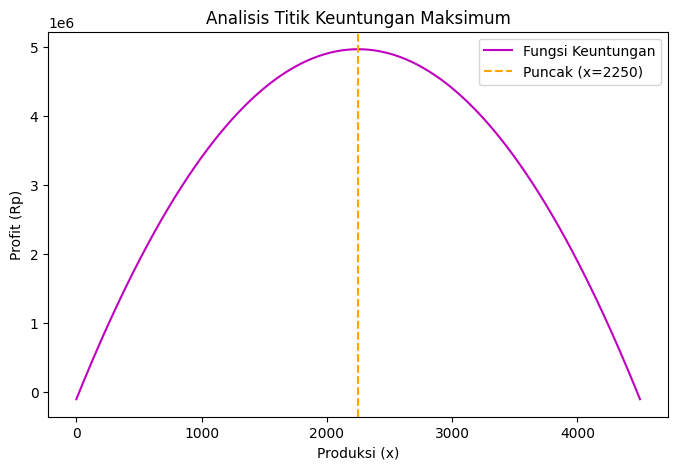

In [6]:
x_profit = np.linspace(0, 4500, 500)
p_profit = -x_profit**2 + 4500*x_profit - 100000
plt.plot(x_profit, p_profit, 'm-', label='Fungsi Keuntungan')
plt.axvline(2250, color='orange', linestyle='--', label='Puncak (x=2250)')
plt.title('Analisis Titik Keuntungan Maksimum')
plt.xlabel('Produksi (x)')
plt.ylabel('Profit (Rp)')
plt.legend()
plt.show()

### 🏁 5. Kesimpulan Optimasi
Secara matematis, UMKM ini memiliki potensi profit sangat besar hingga batas 2.250 cup. Namun, dalam praktek harian, fokus sebaiknya pada menjaga pertumbuhan stabil di angka 100-200 cup sesuai kapasitas fisik toko.